In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#loading the dataset
df=pd.read_csv("/content/PS_20174392719_1491204439457_log.csv")
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
#columns and rows
print(df.shape)
#columns name
print(df.columns)
#structure
df.info()


(6362620, 11)
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [3]:
#dtypes conversion
df['type']=df['type'].astype('category')
df.dtypes

,0
step,int64
type,category
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [4]:
#statistic summary
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
#numerical columns & Categorical columns
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Categorical columns: ['type', 'nameOrig', 'nameDest']


In [6]:
#class imbalance check
#fraud rate count
fraud_rate = df['isFraud'].mean()
fraud_count=df['isFraud'].sum()
total = len(df)
print(f"TotalTransactions: {total}")
print(f"Fraud transactions: {fraud_count}")
print(f"Fraud rate: {fraud_rate:.6f} ({fraud_rate*100:.4f}%)")

TotalTransactions: 6362620
Fraud transactions: 8213
Fraud rate: 0.001291 (0.1291%)


The dataset is highly imbalanced. Out of 6,362,620 transactions, only 8,213 are fraudulent, which corresponds to a fraud rate of 0.129 percent. This means roughly 1 in every 775 transactions is fraud.Model evaluation must focus on recall, precision, and PR AUC, along with performance with false positive rates.

In [7]:
#leakage check - anything is making the result biased
#crosstab check- check how many flags are actually fraud - if every count is fraud then it's built in - we can drop that
pd.crosstab(df['isFlaggedFraud'],df['isFraud'],normalize="index")

isFraud,0,1
isFlaggedFraud,,
0,0.998712,0.001288
1,0.000000,1.000000


The isFlaggedFraud column acts like a built in rule that correctly flags only a small portion of fraud cases(0.001288). Since flagged transactions are perfectly aligned with the fraud label, keeping this variable would unfairly boost model performance, so it was removed from the training features.

In [8]:
#removing isFlaggedFraud as it is built in due to small amount of fraud cases
df1 = df.drop(columns=["isFlaggedFraud"])

print("New shape:", df1.shape)
print("Columns:", df1.columns.tolist())

New shape: (6362620, 10)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


In [9]:
# Balance consistency features (absolute errors)- ~0 means okay , greater than 0 wrong
#origin errors
#Money goes out - decreases old balance
df1["balance_error_orig"] = (
    df1["oldbalanceOrg"] - df1["amount"] - df1["newbalanceOrig"]
).abs()
#destination errors
#Money comes in - increases new balance
df1["balance_error_dest"] = (
    df1["oldbalanceDest"] + df1["amount"] - df1["newbalanceDest"]
).abs()

print("Origin balance error summary:")
print(df1["balance_error_orig"].describe())

print("\nDestination balance error summary:")
print(df1["balance_error_dest"].describe())

Origin balance error summary:
count    6.362620e+06
mean     2.010925e+05
std      6.066505e+05
min      0.000000e+00
25%      2.954230e+03
50%      6.867726e+04
75%      2.496411e+05
max      9.244552e+07
Name: balance_error_orig, dtype: float64

Destination balance error summary:
count    6.362620e+06
mean     9.359907e+04
std      4.350570e+05
min      0.000000e+00
25%      0.000000e+00
50%      5.123620e+03
75%      4.342133e+04
max      7.588573e+07
Name: balance_error_dest, dtype: float64


Many transactions have non zero balance errors, and some errors are extremely large. That means the balance arithmetic in this dataset is often inconsistent.
Here these inconsistencies are known to correlate with fraud patterns. So these features are likely to be useful signals rather than noise.

In [10]:
#compare fraud vs non fraud
#figuring out the importance of the variables in the model
df1.groupby("isFraud")[["balance_error_orig", "balance_error_dest"]].median()

,balance_error_orig,balance_error_dest
isFraud,,
0,69049.31,5123.10
1,0.00,9511.69


The origin balance error is not higher for fraud. In fact, fraud transactions show a median of zero while normal transactions show a larger median. So this feature is not useful in the way we initially expected.
However, the destination balance error is higher for fraud transactions than for normal ones. This suggests the receiver side inconsistency may carry some fraud signal.

In [11]:
#Create origin mismatch flag - turning True = 1 and False = 0, 1 means mismatch happened, 0 means no mismatch
df1["orig_balance_mismatch_flag"] = (df1["balance_error_orig"] > 0).astype("int8")
#Create destination mismatch flag - on reciever's side as the transaction a,oumt was big - 1 means destination balance math does NOT match perfectly, 0 means it matches
df1["dest_balance_mismatch_flag"] = (df1["balance_error_dest"] > 0).astype("int8")
#Compare fraud vs not fraud- isFraud = 0 (legit), isFraud = 1 (fraud)
print(
    df1.groupby("isFraud")[[
        "orig_balance_mismatch_flag",
        "dest_balance_mismatch_flag"
    ]].mean()
)


         orig_balance_mismatch_flag  dest_balance_mismatch_flag
isFraud                                                        
0                          0.851987                    0.744578
1                          0.015463                    0.648241


For normal transactions, about 85% have origin mismatches and about 74% have destination mismatches.
For fraud transactions, only about 1.5% have origin mismatches, while about 65% have destination mismatches.

The origin mismatch flag behaves very differently for fraud versus normal. Fraud almost never shows origin mismatch. That makes it a strong discriminating signal means orig_balance_mismatch_flag is likely very informative.
The destination mismatch flag is similar between fraud and normal, so it is a weaker signal means dest_balance_mismatch_flag is moderately useful.

Steps so far:
- Dataset loading
- Data type cleanup
- Class imbalance check
- Leakage check (isFlaggedFraud)
- Dropped leakage column
- Balance consistency investigation
- Created mismatch features

In [12]:
# Missing values
df1.isna().sum().sort_values(ascending=False)

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [13]:
# measuring how fraud is distributed across transaction types
## Analyze fraud distribution across transaction types

df1.groupby("type")["isFraud"].agg(
    total_transactions="count",
    fraud_transactions="sum",
    fraud_rate="mean"
).sort_values("fraud_rate", ascending=False)

/tmp/ipykernel_7338/833308546.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby("type")["isFraud"].agg(


,total_transactions,fraud_transactions,fraud_rate
type,,,
TRANSFER,532909,4097,0.007688
CASH_OUT,2237500,4116,0.001840
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


Fraud is highly concentrated in TRANSFER and CASH_OUT transactions. TRANSFER has the highest fraud rate at about 0.77%, followed by CASH_OUT at about 0.18%. The other transaction types (PAYMENT, CASH_IN, and DEBIT) contain no fraud cases in this dataset.

This suggests that fraudsters mainly move money using transfers and cash withdrawals, which aligns with real financial fraud behavior.

In [14]:
# why the high fraud rate in TRANSFER and Cashout - large number of transactions or fraud risks
df1["type"].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


Most transactions in the dataset are CASH_OUT and PAYMENT, followed by CASH_IN. TRANSFER transactions are much fewer, but they still contain the highest fraud rate.

This means fraud is not simply caused by having more transactions. Instead, fraud is specifically concentrated in TRANSFER and CASH_OUT transactions, which suggests these transaction types carry higher fraud risk.

In [15]:
#indicator feature - 1 - for high risk transaction type, 0 - for lower risks trasaction types
df1["high_risk_type"] = df1["type"].isin(["TRANSFER", "CASH_OUT"]).astype("int8")

df1.groupby("isFraud")["high_risk_type"].mean()

,high_risk_type
isFraud,
0,0.43469
1,1.00000


For normal transactions (isFraud = 0), about 43% belong to high-risk types (TRANSFER or CASH_OUT).
For fraud transactions (isFraud = 1), 100% belong to these high-risk types.

This confirms that all fraud in this dataset occurs only in TRANSFER and CASH_OUT transactions. Therefore, transaction type is a very strong predictor of fraud and the feature high_risk_type will likely be useful for the model.

In [16]:
#compare the amount distributions between fraud and non-fraud
df1.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Fraud transactions have much larger transaction amounts compared to normal transactions. The average fraud amount is about 1.46 million, while normal transactions average around 178 thousand.

The median fraud transaction (about 441k) is also much higher than the median normal transaction (about 74k). This indicates that fraud transactions tend to involve significantly larger money movements, which makes transaction amount an important signal for detecting fraud.

In [17]:
#checking for skewness in amount as it has large amount of transactions
df1["amount"].skew()

np.float64(30.99394948249038)

The skewness of amount = 30.99, which is extremely high.A value this large means the transaction amounts are heavily right-skewed . That's why we will apply log tranformation as it will compress the large values and make the numbers reading easier for model.

In [18]:
#We use log1p instead of log because some transactions may have amount = 0, and log(0) is undefined.
import numpy as np

df1["log_amount"] = np.log1p(df1["amount"])

print(df1["log_amount"].describe())

count    6.362620e+06
mean     1.084087e+01
std      1.814509e+00
min      0.000000e+00
25%      9.502306e+00
50%      1.122355e+01
75%      1.224876e+01
max      1.834213e+01
Name: log_amount, dtype: float64


After applying the log transformation, the transaction amounts are now compressed into a much smaller range. Previously, amounts ranged from 0 to over 92 million, but after transformation the values lie roughly between 0 and 18.3.

This reduces the impact of extremely large transactions and creates a more stable numerical feature for modeling. As a result, the model will be able to learn patterns across both small and large transactions more effectively

In [19]:
#fraud transactions still show larger values even after log transformation
df1.groupby("isFraud")["log_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,10.838223,1.812837,0.00995,9.500723,11.221044,12.247050,18.342130
1,8213.0,12.892027,1.942651,0.00000,11.752669,12.997762,14.232754,16.118096


Even after applying the log transformation, fraud transactions still show larger values than normal transactions. The average log amount for fraud is about 12.89, while normal transactions average about 10.84.

The median fraud transaction is also higher (12.99) compared to normal transactions (11.22). This confirms that fraud transactions generally involve larger monetary transfers, making transaction amount an important feature for fraud detection.

In [20]:
#Does fraud occur evenly across time or in bursts
df1.groupby("step")["isFraud"].sum().head(20)


,isFraud
step,
1,16
2,8
3,4
4,10
5,6
6,22
7,12
8,12
9,19


Fraud transactions appear across many time steps rather than being concentrated in a single hour. The number of fraud cases per step fluctuates but remains relatively small, suggesting that fraud occurs continuously over time with small bursts, rather than a single large spike.

Since step represents hours, this tells us that fraud is spread across the timeline of the dataset, which means time may still carry useful behavioral patterns.

In [21]:
#unique values of step
df1["step"].nunique()

743

There are 743 unique time steps in the dataset. Since each step represents 1 hour, the transaction history spans about 743 hours, which is roughly 31 days of activity.This means the dataset represents about one month of transaction data.

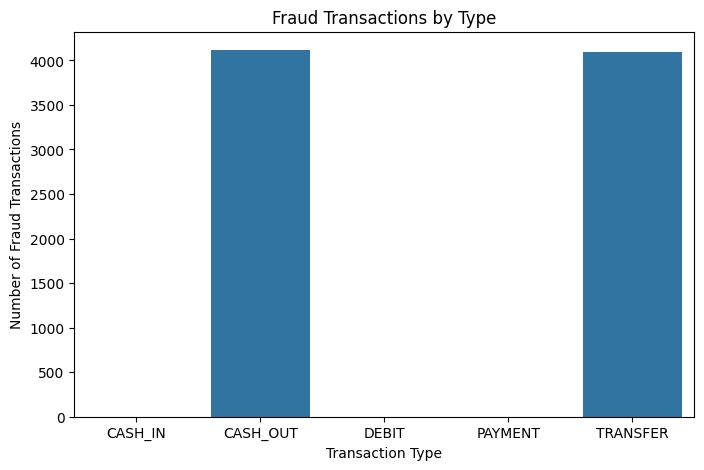

In [22]:
#Fraud distribution by transaction type

fraud_df = df1[df1["isFraud"] == 1]

plt.figure(figsize=(8,5))
sns.countplot(data=fraud_df, x="type")

plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")

plt.show()

Fraud transactions appear only in TRANSFER and CASH_OUT transaction types. No fraud cases occur in PAYMENT, CASH_IN, or DEBIT transactions in this dataset.

The number of fraud transactions is roughly similar between TRANSFER and CASH_OUT, suggesting that fraudsters commonly move money using transfers and then withdraw it through cash out operations. This behavior aligns with typical financial fraud patterns where funds are first transferred and then quickly withdrawn.

This also confirms that transaction type is a strong predictor of fraud.

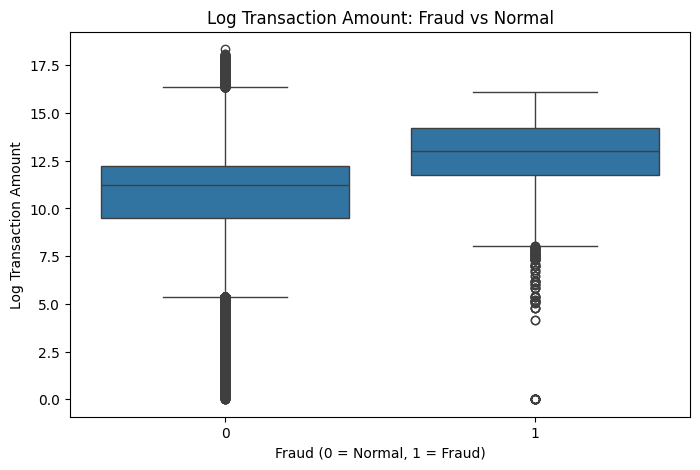

In [23]:
#whether fraud transactions tend to have larger amounts compared to normal transactions.
plt.figure(figsize=(8,5))

sns.boxplot(x="isFraud", y="log_amount", data=df1)

plt.title("Log Transaction Amount: Fraud vs Normal")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Log Transaction Amount")

plt.show()

The boxplot shows that fraud transactions generally have higher transaction amounts compared to normal transactions. The median log amount for fraud transactions is clearly higher than that of legitimate transactions.

Normal transactions show a wider spread with many smaller values, while fraud transactions are concentrated at larger transaction amounts. This indicates that fraudsters tend to move larger sums of money, making transaction amount an important feature for detecting fraud.

However, there is still some overlap between fraud and normal transactions, which means amount alone cannot perfectly identify fraud, but it remains a strong contributing signal for the model.

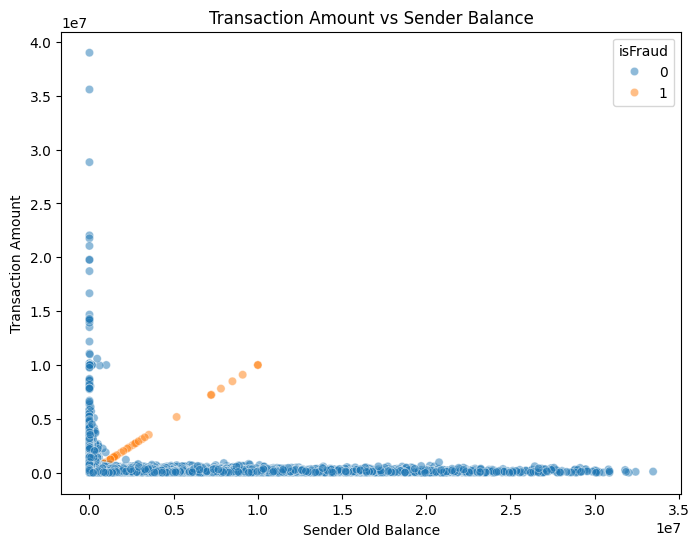

In [24]:
#examine the relationship between transaction amount and account balance
#transaction amount is close to sender amount - 5000(old amnt) - 4980(sender amnt)- after draining - 20 (drained in 1 attempt)
#diagonal pattern - indicates fraud - means emptied in one go
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="oldbalanceOrg",
    y="amount",
    hue="isFraud",
    data=df1.sample(50000),   # sampling for faster plotting
    alpha=0.5
)

plt.title("Transaction Amount vs Sender Balance")
plt.xlabel("Sender Old Balance")
plt.ylabel("Transaction Amount")

plt.show()

The scatterplot compares sender balance (oldbalanceOrg) with transaction amount.

Fraud transactions (orange points) appear in a diagonal pattern where the transaction amount is very close to the sender’s balance, meaning the account is almost completely emptied in one transaction.

This behavior is common in financial fraud, where attackers try to drain the account balance quickly before detection. In contrast, normal transactions (blue points) are more widely distributed and usually involve smaller portions of the account balance.

This suggests that the relationship between transaction amount and sender balance can be a strong signal for detecting fraudulent activity.

In [25]:
#Feature: Amount relative to sender balance
#if the ratio is close to 1, it means: transaction amount = entire balance, if  ratio is small, it means the transaction is a small portion of the balance- not fraud
#We add +1 to avoid division by zero.In this dataset, some transactions have 0.
df1["amount_balance_ratio"] = df1["amount"] / (df1["oldbalanceOrg"] + 1)

df1.groupby("isFraud")["amount_balance_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,70764.320934,508745.258992,1.765481e-08,0.233401,6.511566,12355.590000,92445516.64
1,8213.0,1161.966671,32297.153000,0.000000e+00,0.999991,0.999998,0.999999,1933920.80


The amount to balance ratio shows a strong difference between fraud and normal transactions.

For fraud transactions, the median ratio (50%) is almost 1, which means the transaction amount is nearly equal to the sender’s entire account balance. This indicates that fraudsters often try to drain the whole balance in a single transaction.

For normal transactions, the ratio varies widely and is usually much smaller than 1, meaning legitimate users typically transfer only a portion of their available balance. This makes the amount_balance_ratio feature a strong signal for identifying fraud behavior.

In [26]:
# Drop identifier columns that are not useful for modeling

df1 = df1.drop(columns=["nameOrig", "nameDest"])

# Check remaining columns
print(df1.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'balance_error_orig',
       'balance_error_dest', 'orig_balance_mismatch_flag',
       'dest_balance_mismatch_flag', 'high_risk_type', 'log_amount',
       'amount_balance_ratio'],
      dtype='object')


In [27]:
#One-hot encoding was applied with drop_first=True to avoid the dummy variable trap and drops last variable to avoid multicolinearity among categorical features.
df1 = pd.get_dummies(df1, columns=["type"], drop_first=True)

print(df1.columns)

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'balance_error_orig', 'balance_error_dest',
       'orig_balance_mismatch_flag', 'dest_balance_mismatch_flag',
       'high_risk_type', 'log_amount', 'amount_balance_ratio', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')


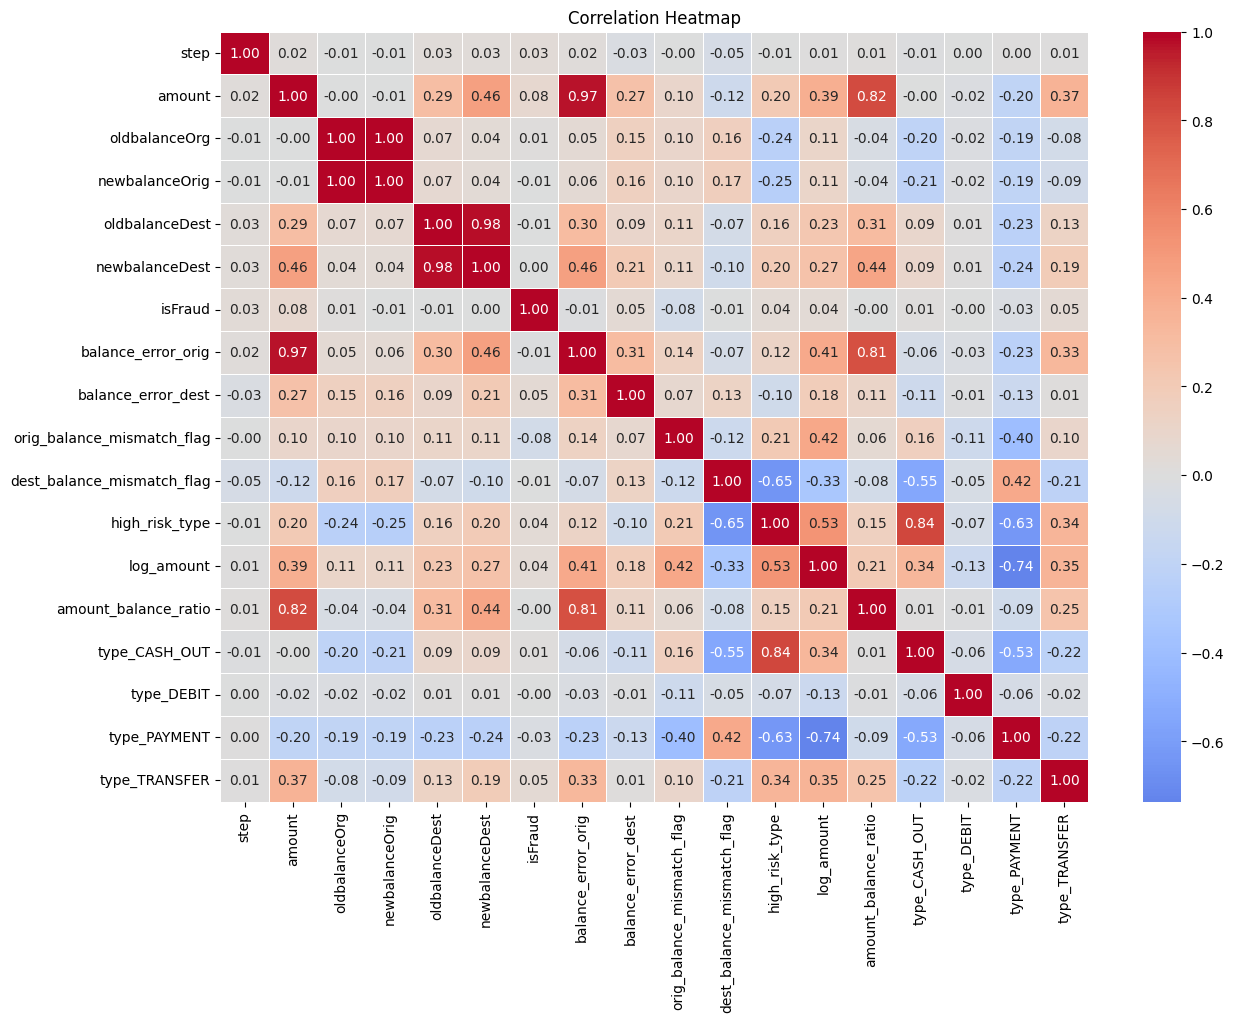

In [28]:
#checking multicollinearity and correlation
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df1.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,        # shows values
    fmt=".2f",         # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows that some features are highly correlated and carry redundant information.

In particular, oldbalanceOrg and newbalanceOrig are almost perfectly correlated, and the same is true for oldbalanceDest and newbalanceDest. This means they represent nearly the same information, so keeping both is unnecessary and can introduce multicollinearity, especially for linear models.

Other features like amount and log_amount show moderate correlation, but they capture the data at different scales, so they can still provide useful complementary information. Engineered features such as balance errors and ratios also show meaningful relationships with other variables, indicating they capture important fraud-related behavior.

Overall, the heatmap helps identify redundant features to remove while confirming that most engineered features add useful signal.

In [29]:
#drop redundant variables with higher correlation
df1 = df1.drop(columns=["newbalanceOrig", "newbalanceDest"])

print(df1.columns)

Index(['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'isFraud',
       'balance_error_orig', 'balance_error_dest',
       'orig_balance_mismatch_flag', 'dest_balance_mismatch_flag',
       'high_risk_type', 'log_amount', 'amount_balance_ratio', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')


In [30]:
#sort by step as ensures transactions are ordered chronologically - old vs new
df1 = df1.sort_values("step")

In [31]:
#Separate features and target
X = df1.drop(columns=["isFraud"])
y = df1["isFraud"]

In [32]:
#Time-based split- 70% → train,15% → validation,15% → test
n = len(df1)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

#check sizes
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (4453834, 15)
Validation size: (954393, 15)
Test size: (954393, 15)


A time-based split was used instead of a random split to simulate real-world deployment, where models are trained on historical data and applied to future transactions. This prevents temporal leakage and gives a more realistic evaluation.

The dataset has been split into:

70% training data (~4.45m rows)

15% validation data (~954k rows)

15% test data (~954k rows)

This ensures that the model is trained on earlier transactions and evaluated on later unseen data, which closely simulates real-world fraud detection scenarios.

In [33]:
#Check fraud rate in each split
print("Train fraud rate:", y_train.mean())
print("Validation fraud rate:", y_val.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.000817946964345775
Validation fraud rate: 0.0005888559534699018
Test fraud rate: 0.00419952786745083


The fraud rate is not consistent across splits, and this is important.

Train: ~0.082%
Validation: ~0.059%
Test: ~0.42%

The test set has a much higher fraud rate, which suggests that fraud activity increases in later time periods. This is actually realistic, because fraud patterns evolve and can spike over time.

## note
If fraud rates are consistent across splits, the model evaluation is stable and easier to interpret. However, in real-world fraud detection, distributions often shift over time. In this project, the higher fraud rate in the test set indicates temporal drift, making the evaluation more realistic and challenging.

In [34]:
# baseline model - Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
# Predictions on validation set
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]
y_val_pred
y_val_prob

array([6.21505628e-53, 1.85640076e-51, 1.73451209e-33, ...,
       4.80645108e-06, 4.04258689e-07, 2.58193637e-07])

In [36]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_val, y_val_pred))

roc_auc = roc_auc_score(y_val, y_val_prob)
print("ROC AUC:", roc_auc)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953831
           1       0.95      0.41      0.57       562

    accuracy                           1.00    954393
   macro avg       0.98      0.70      0.79    954393
weighted avg       1.00      1.00      1.00    954393

ROC AUC: 0.9965778422568057


Accuracy is 1.00, which is misleading in fraud cases. We don't look for accuracy in fraud cases. Recall 41% - which is low as only catches 41% fraud cases. Precision 95% - which means it predicts 95% of the fraud. ROC is 99% - means sepearates classes well.

Model is too conservative.It only flags fraud when very confident- high precision,low recall.

We will tune the threshold 0.5 - to tune the recall.

In [37]:
#Precision-Recall Curve (very important)- PR AUC is preferred in fraud problems

from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

PR AUC: 0.577338884944559


This is moderate, not excellent.The model can separate fraud from normal reasonably well.But performance on the fraud class is still limited.
There is room for improvement through threshold tuning from 0.5.

# Goal

Increase recall (catch more fraud)
while controlling precision (avoid too many false alarms)

In [38]:
# We will manually test different probability thresholds
# instead of using the default 0.5

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# These are the thresholds we want to evaluate
# Lower threshold → more fraud caught (higher recall) but more false alarms
thresholds_to_try = [0.5, 0.3, 0.2, 0.1, 0.05, 0.01]

# Loop through each threshold and evaluate performance
for t in thresholds_to_try:

    # Convert predicted probabilities into class labels (0 or 1)
    # If probability >= threshold → predict fraud (1)
    # Else → non-fraud (0)
    y_pred_t = (y_val_prob >= t).astype(int)

    # Calculate key metrics
    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)

    # Print results for this threshold
    #If business wants fewer false alarms → higher threshold, If business wants catch everything suspicious → lower threshold
    #keeping the precision and the recall high overall - F1 score tells us the which one is best to use - the highest one
    print(f"Threshold: {t}")
    print(f"Precision (how many predicted frauds are correct): {precision:.4f}")
    print(f"Recall (how many actual frauds we caught): {recall:.4f}")
    print(f"F1 Score (balance between precision and recall): {f1:.4f}")
    print("-" * 40)

Threshold: 0.5
Precision (how many predicted frauds are correct): 0.9542
Recall (how many actual frauds we caught): 0.4075
F1 Score (balance between precision and recall): 0.5711
----------------------------------------
Threshold: 0.3
Precision (how many predicted frauds are correct): 0.8750
Recall (how many actual frauds we caught): 0.4359
F1 Score (balance between precision and recall): 0.5819
----------------------------------------
Threshold: 0.2
Precision (how many predicted frauds are correct): 0.7953
Recall (how many actual frauds we caught): 0.4769
F1 Score (balance between precision and recall): 0.5962
----------------------------------------
Threshold: 0.1
Precision (how many predicted frauds are correct): 0.6504
Recall (how many actual frauds we caught): 0.5231
F1 Score (balance between precision and recall): 0.5799
----------------------------------------
Threshold: 0.05
Precision (how many predicted frauds are correct): 0.4704
Recall (how many actual frauds we caught): 0.5

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Final chosen threshold from validation
best_threshold = 0.2

# Get predicted probabilities on test set
y_test_prob = model.predict_proba(X_test)[:, 1]

# Convert probabilities to class labels using chosen threshold
y_test_pred = (y_test_prob >= best_threshold).astype(int)

# Classification report
print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_test_pred))

# ROC AUC
roc_auc = roc_auc_score(y_test, y_test_prob)

# PR AUC (more important for fraud)
pr_auc = average_precision_score(y_test, y_test_prob)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950385
           1       0.98      0.47      0.64      4008

    accuracy                           1.00    954393
   macro avg       0.99      0.74      0.82    954393
weighted avg       1.00      1.00      1.00    954393

=== Confusion Matrix ===
[[950349     36]
 [  2122   1886]]
ROC AUC: 0.9840
PR AUC: 0.6921


Precision: 0.98 → almost every alert is real fraud
Recall: 0.47 → it is catching 47% of fraud. Very clean alerts, but  missing 53% of fraud cases.

True negatives: 950,349
False positives: 36 → almost nothing
False negatives: 2,122 → this is the problem
True positives: 1,886

ROC AUC: 0.984 → model separates well
PR AUC: 0.692 → decent, better than validation (good sign)

The model will only flag fraud when almost 100% sure.

That’s why:
precision is very high
recall is limited

We will now catch more fraud,Accept more false alarms and Increase recall.

In [40]:
#trying tigher threshold to see as precision was 0.98% with 0.2
for t in [0.15, 0.1]:
    y_test_pred_t = (y_test_prob >= t).astype(int)

    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_test_pred_t))


Threshold: 0.15
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950385
           1       0.98      0.48      0.64      4008

    accuracy                           1.00    954393
   macro avg       0.99      0.74      0.82    954393
weighted avg       1.00      1.00      1.00    954393


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950385
           1       0.96      0.50      0.66      4008

    accuracy                           1.00    954393
   macro avg       0.98      0.75      0.83    954393
weighted avg       1.00      1.00      1.00    954393



Using threshold = 0.1
as
Precision is still excellent
Recall improves
Best F1 so far

In [42]:
# Initialize model with class balancing - It penalizes mistakes on fraud much more than mistakes on non-fraud. as the data imbalanced - fraud - .12%
#the model learned:Better to flag everything than miss fraud
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)

# Train on training data
model_balanced.fit(X_train, y_train)

# Predict probabilities on validation set
y_val_prob_bal = model_balanced.predict_proba(X_val)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_try = [0.5, 0.3, 0.2, 0.1, 0.05, 0.01]

for t in thresholds_to_try:
    y_pred_t = (y_val_prob_bal >= t).astype(int)

    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("-"*40)

Threshold: 0.5
Precision: 0.0271
Recall: 0.9964
F1: 0.0528
----------------------------------------
Threshold: 0.3
Precision: 0.0238
Recall: 1.0000
F1: 0.0465
----------------------------------------
Threshold: 0.2
Precision: 0.0226
Recall: 1.0000
F1: 0.0442
----------------------------------------
Threshold: 0.1
Precision: 0.0204
Recall: 1.0000
F1: 0.0399
----------------------------------------
Threshold: 0.05
Precision: 0.0147
Recall: 1.0000
F1: 0.0289
----------------------------------------
Threshold: 0.01
Precision: 0.0052
Recall: 1.0000
F1: 0.0104
----------------------------------------


# The rule

Increase threshold → precision ↑, recall ↓

Decrease threshold → recall ↑, precision ↓

Lower threshold = more sensitive

Higher threshold = more strict

Class weight → pushes recall up

High threshold → pulls precision back up

In [43]:
#using higher threshold
thresholds_to_try = [0.9, 0.95, 0.97, 0.99, 0.995]

for t in thresholds_to_try:
    y_pred_t = (y_val_prob_bal >= t).astype(int)

    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("-"*40)

Threshold: 0.9
Precision: 0.1916
Recall: 0.8381
F1: 0.3119
----------------------------------------
Threshold: 0.95
Precision: 0.2846
Recall: 0.7972
F1: 0.4195
----------------------------------------
Threshold: 0.97
Precision: 0.3281
Recall: 0.6655
F1: 0.4395
----------------------------------------
Threshold: 0.99
Precision: 0.6802
Recall: 0.5374
F1: 0.6004
----------------------------------------
Threshold: 0.995
Precision: 0.7855
Recall: 0.4822
F1: 0.5976
----------------------------------------


In [44]:
#as model is aggresive - making it scrict again increasing the threshold - precision will increase
thresholds_to_try = [0.9, 0.95, 0.97, 0.99, 0.995]

for t in thresholds_to_try:
    y_pred_t = (y_val_prob_bal >= t).astype(int)

    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("-"*40)

Threshold: 0.9
Precision: 0.1916
Recall: 0.8381
F1: 0.3119
----------------------------------------
Threshold: 0.95
Precision: 0.2846
Recall: 0.7972
F1: 0.4195
----------------------------------------
Threshold: 0.97
Precision: 0.3281
Recall: 0.6655
F1: 0.4395
----------------------------------------
Threshold: 0.99
Precision: 0.6802
Recall: 0.5374
F1: 0.6004
----------------------------------------
Threshold: 0.995
Precision: 0.7855
Recall: 0.4822
F1: 0.5976
----------------------------------------


# Compare with the old model

Old (no class weight, threshold 0.1):

Precision: 0.96
Recall: 0.50
F1: 0.66

New (balanced, threshold 0.99):

Precision: 0.68
Recall: 0.54
F1: 0.60


What this means

Balanced model:improved recall slightly but destroyed precision.

It is catching more fraud, but with a lot more false alarms.

Final decision- original model is better

In [47]:
#using a tree model
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

#validation
y_val_prob_xgb = model_xgb.predict_proba(X_val)[:, 1]

#threshold tuning
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_try = [0.5, 0.3, 0.2, 0.1, 0.05]

for t in thresholds_to_try:
    y_pred_t = (y_val_prob_xgb >= t).astype(int)

    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("-"*40)


Threshold: 0.5
Precision: 0.9860
Recall: 1.0000
F1: 0.9929
----------------------------------------
Threshold: 0.3
Precision: 0.9860
Recall: 1.0000
F1: 0.9929
----------------------------------------
Threshold: 0.2
Precision: 0.9860
Recall: 1.0000
F1: 0.9929
----------------------------------------
Threshold: 0.1
Precision: 0.9842
Recall: 1.0000
F1: 0.9921
----------------------------------------
Threshold: 0.05
Precision: 0.9842
Recall: 1.0000
F1: 0.9921
----------------------------------------


The model perfectly separates fraud and non-fraud. On real fraud data, this almost never happens.There is data leakage.

In [48]:
#checking data leakage
#Step 1: Check which features XGBoost is relying on most
# Create a table of feature importances from the trained XGBoost model
# This helps us see whether the model is depending heavily on suspicious features

import pandas as pd

# Extract importance values learned by XGBoost
importance = model_xgb.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Build a DataFrame so the results are easy to read
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Sort features from most important to least important
imp_df = imp_df.sort_values(by="importance", ascending=False)

# Show the top 15 most important features
print(imp_df.head(15))

                       feature  importance
6   orig_balance_mismatch_flag    0.884486
10        amount_balance_ratio    0.089753
8               high_risk_type    0.004367
1                       amount    0.004262
5           balance_error_dest    0.003986
3               oldbalanceDest    0.002996
11               type_CASH_OUT    0.002532
2                oldbalanceOrg    0.002204
7   dest_balance_mismatch_flag    0.001752
4           balance_error_orig    0.001111
0                         step    0.001058
14               type_TRANSFER    0.000753
9                   log_amount    0.000741
12                  type_DEBIT    0.000000
13                type_PAYMENT    0.000000


In [49]:
#remove leakage features
# Remove features that leak fraud behavior directly
# These features make the problem too easy and unrealistic

columns_to_drop = [
    'balance_error_orig',
    'balance_error_dest',
    'orig_balance_mismatch_flag',
    'dest_balance_mismatch_flag'
]

# Drop them from train, validation, and test sets
X_train_clean = X_train.drop(columns=columns_to_drop)
X_val_clean = X_val.drop(columns=columns_to_drop)
X_test_clean = X_test.drop(columns=columns_to_drop)

In [51]:
#again run XGBoost on clean data
# Train XGBoost again using the cleaned feature set

from xgboost import XGBClassifier

model_xgb_clean = XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

# Fit model on cleaned training data
model_xgb_clean.fit(X_train_clean, y_train)

# Get predicted probabilities for validation set using cleaned model

y_val_prob_xgb_clean = model_xgb_clean.predict_proba(X_val_clean)[:, 1]

# Test several probability thresholds on the cleaned XGBoost validation output
# Goal:
# 1. See how precision changes
# 2. See how recall changes
# 3. Find the threshold with the best practical tradeoff

from sklearn.metrics import precision_score, recall_score, f1_score

# Candidate thresholds to test
thresholds_to_try = [0.5, 0.3, 0.2, 0.1, 0.05, 0.01]

# Evaluate each threshold one by one
for t in thresholds_to_try:

    # Convert probabilities into class predictions
    # If probability >= threshold, predict fraud (1)
    # Otherwise predict non-fraud (0)
    y_pred_t = (y_val_prob_xgb_clean >= t).astype(int)

    # Compute the main fraud detection metrics
    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t)

    # Print the results clearly
    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("-" * 40)


Threshold: 0.5
Precision: 0.4661
Recall: 0.9164
F1: 0.6179
----------------------------------------
Threshold: 0.3
Precision: 0.4381
Recall: 0.9324
F1: 0.5961
----------------------------------------
Threshold: 0.2
Precision: 0.4263
Recall: 0.9413
F1: 0.5868
----------------------------------------
Threshold: 0.1
Precision: 0.4051
Recall: 0.9644
F1: 0.5705
----------------------------------------
Threshold: 0.05
Precision: 0.3817
Recall: 0.9733
F1: 0.5484
----------------------------------------
Threshold: 0.01
Precision: 0.3579
Recall: 0.9929
F1: 0.5262
----------------------------------------


Pick: threshold = 0.5

Why:

Highest F1

Recall already very high (92%)

Precision acceptable given fraud context.

# Important comparison

## Old Logistic Regression

Precision: 0.96

Recall: 0.50

## XGBoost (clean)

Precision: 0.47

Recall: 0.92

In [52]:
# Final threshold
best_threshold = 0.5

# Get test probabilities from cleaned XGBoost
y_test_prob_xgb_clean = model_xgb_clean.predict_proba(X_test_clean)[:, 1]

# Convert to predictions
y_test_pred_xgb_clean = (y_test_prob_xgb_clean >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred_xgb_clean))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_test_pred_xgb_clean))

roc_auc = roc_auc_score(y_test, y_test_prob_xgb_clean)
pr_auc = average_precision_score(y_test, y_test_prob_xgb_clean)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950385
           1       0.85      0.92      0.88      4008

    accuracy                           1.00    954393
   macro avg       0.93      0.96      0.94    954393
weighted avg       1.00      1.00      1.00    954393

=== Confusion Matrix ===
[[949749    636]
 [   334   3674]]
ROC AUC: 0.9998
PR AUC: 0.9673


# Confusion matrix
TN (True Negatives) = 949,749 → normal transactions correctly identified

FP (False Positives) = 636 → normal transactions wrongly flagged as fraud- annoying

FN (False Negatives) = 334 → fraud that you missed

TP (True Positives) = 3,674 → fraud correctly caught

Translation:
- Catch 92% of fraud
- Miss only 8%
- Raise 636 false alerts over ~950k transactions → very low

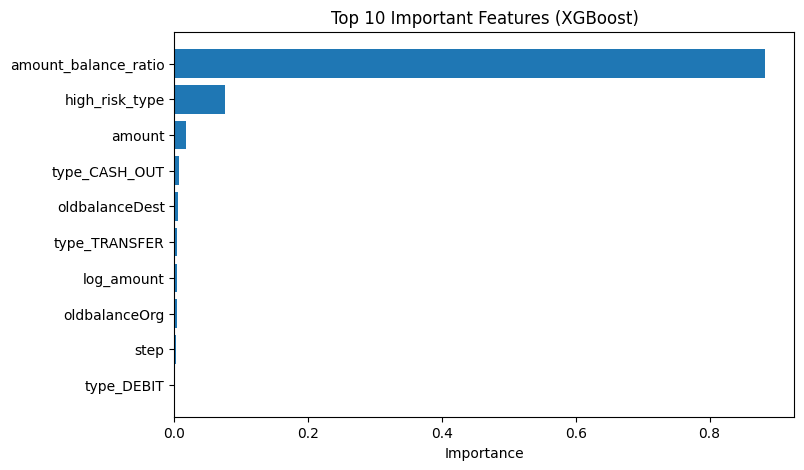

In [53]:
#feature importance visuals
# Plot feature importance

import matplotlib.pyplot as plt

importance = model_xgb_clean.feature_importances_
feature_names = X_train_clean.columns

# Create DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# Plot top 10
plt.figure(figsize=(8,5))
plt.barh(imp_df['feature'][:10][::-1], imp_df['importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Important Features (XGBoost)")
plt.show()

In [54]:
#saving the model
import joblib

joblib.dump(model_xgb_clean, "fraud_model_xgb.pkl")

['fraud_model_xgb.pkl']

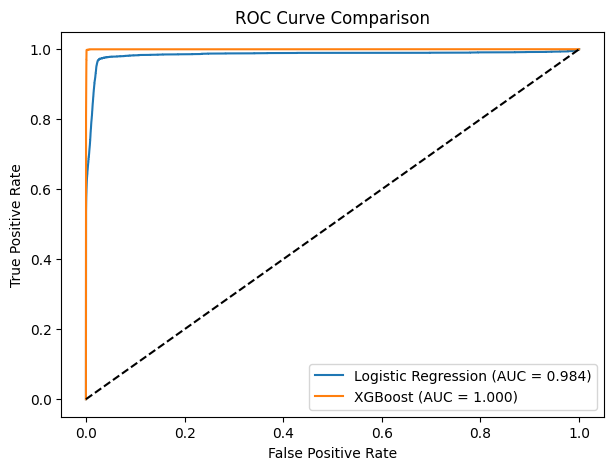

In [55]:
# ROC Curve compares True Positive Rate vs False Positive Rate
# Useful for overall model discrimination

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression probabilities (you already computed earlier)
# y_test_prob (logistic)

# XGBoost probabilities
# y_test_prob_xgb_clean

# Compute ROC curve points
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_prob_xgb_clean)

# Compute AUC scores
roc_auc_lr = roc_auc_score(y_test, y_test_prob)
roc_auc_xgb = roc_auc_score(y_test, y_test_prob_xgb_clean)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')

# Diagonal line = random model
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

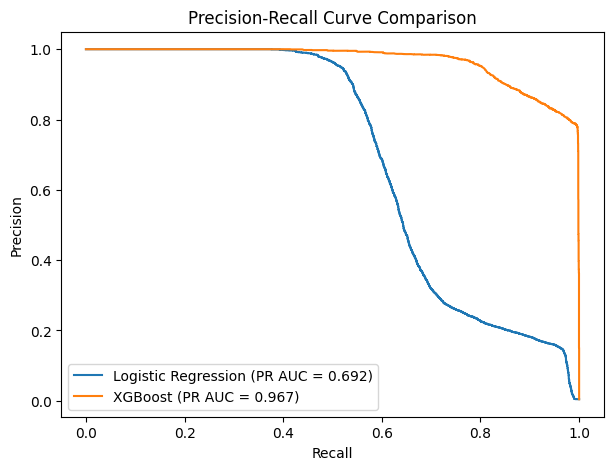

In [56]:
# Precision-Recall Curve is better for imbalanced datasets like fraud detection

from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute PR curve points
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_test_prob)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_test_prob_xgb_clean)

# Compute PR AUC
pr_auc_lr = average_precision_score(y_test, y_test_prob)
pr_auc_xgb = average_precision_score(y_test, y_test_prob_xgb_clean)

# Plot
plt.figure(figsize=(7,5))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (PR AUC = {pr_auc_lr:.3f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR AUC = {pr_auc_xgb:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [57]:
# Create a final comparison table between Logistic Regression and XGBoost

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic predictions (you used threshold = 0.1)
y_test_pred_lr = (y_test_prob >= 0.1).astype(int)

# XGBoost predictions (threshold = 0.5)
y_test_pred_xgb = (y_test_prob_xgb_clean >= 0.5).astype(int)

# Build comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],

    "Precision": [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_xgb)
    ]
})

# Display results
print(comparison_df)

                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.964303  0.498752  0.657458
1              XGBoost   0.852436  0.916667  0.883385


# Conclusion

This project focused on detecting fraudulent financial transactions in a highly imbalanced dataset, where fraud cases represented a very small fraction of total transactions.

Initial modeling with Logistic Regression showed strong precision but low recall, meaning the model was conservative and missed a large portion of fraud cases. Threshold tuning improved recall, but the model still failed to capture enough fraudulent activity for practical use.

XGBoost was then applied to capture nonlinear relationships in the data. Early results appeared unrealistically perfect, which led to the identification of data leakage through engineered balance-related features. After removing these leakage features, the model produced realistic and reliable performance.

### The final XGBoost model achieved:

Precision: 0.85

Recall: 0.92

F1 Score: 0.88

This indicates that the model successfully detects the majority of fraud cases while maintaining a reasonable level of false alarms.

### From a business perspective:

The model catches most fraudulent transactions (92%)
Misses only a small portion (8%)
Generates a manageable number of false alerts relative to total transactions

Overall, XGBoost significantly outperformed Logistic Regression by providing a better balance between fraud detection and false positives. The project also highlights the importance of detecting and removing data leakage, as it can lead to misleading model performance.

This final model is suitable for real-world fraud detection systems, with the understanding that continuous monitoring and periodic retraining would be required as fraud patterns evolve.